# Model A — A3 à A6 : occurrence et croissance conditionnelle

Objectif : évaluer séparément les probabilités de transition et la croissance conditionnelle, puis leurs combinaisons P1 **à titre diagnostique**. CORE uniquement. Aucun champion P1 définitif, aucune prévision 2026, aucun export individuel.

## Protocole temporel

Walk-forward 2023/2024/2025 aux origines 2022/2023/2024-12-31. La fondation reconstruit chaque cohorte historique à sa propre origine ; seuls les labels qualifiés disponibles à D entraînent les modèles. Une paire encore immature ne devient pas automatiquement une non-transition. Les transformations sont ajustées uniquement sur train.

Les effectifs et caractéristiques restent conditionnels à la fidélité du snapshot CRM. La croissance historique est la moyenne par unité des transitions admissibles **alors connues**, selon la baseline P1 existante ; des transitions non encore observables ne sont pas ajoutées. Aucune version historique parfaite n'est revendiquée.

In [1]:
from pathlib import Path
import sys, hashlib, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
sys.path.insert(0,str(ROOT))
from src.evaluation.model_a_evaluation import evaluate_model_a
from src.features.model_dataset import OCCURRENCE_FEATURES, ADMISSIBLE_FEATURES
from src.evaluation.backtest import run_portfolio_baselines
protected=list((ROOT/'data/raw').glob('*.csv'))+list((ROOT/'data/external').glob('*'))
protected=[p for p in protected if p.is_file()]
protected+=list((ROOT/'notebooks').glob('0[1-6]_*.ipynb'))+[ROOT/'notebooks/starter.ipynb',ROOT/'docs/model_a_features.md']
frozen=['docs/modeling_contract.md','src/features/model_dataset.py','src/evaluation/backtest.py','src/same_unit.py','src/rent_economics.py','src/external_data.py']
protected += [ROOT/p for p in frozen]
hashes={p:hashlib.sha256(p.read_bytes()).hexdigest() for p in protected}
for path in frozen:
    original=subprocess.run(['git','show','foundation-v1:'+path],cwd=ROOT,capture_output=True,check=True).stdout
    assert original==(ROOT/path).read_bytes()
leases=pd.read_csv(ROOT/'data/raw/equinoxe_lease_history.csv',dtype={'sPropCode':'string','sUnitCode':'string'})
print('Sources figées vérifiées ; données confidentielles uniquement en mémoire.')


Sources figées vérifiées ; données confidentielles uniquement en mémoire.


## Features CORE et réglages prédéfinis

Les 13 features occurrence et 12 croissance sont conservées ; expiry_month reste réservé à l'occurrence. Aucune feature ENRICHED ou externe. Variables numériques : conversion, imputation médiane train et standardisation pour les modèles linéaires. Catégorielles : valeur manquante explicite et OneHotEncoder(handle_unknown="ignore"). Colonnes entièrement manquantes conservées ; fallback numérique zéro indépendant du futur.

Une configuration fixe par candidat, sans tuning : Logistic L2 C=1, sans pondération des classes ; Ridge alpha=10 ; ElasticNet alpha=0,001 et l1_ratio=0,1 ; HGB learning_rate=0,05, 100 itérations, 7 feuilles, minimum 20 observations par feuille, L2=1. HGB reçoit l'encodage dense et n'utilise pas d'early stopping aléatoire. Seuils préalables : dix observations de chaque classe pour Logistic ; trente transitions pour les modèles de croissance. Sinon seuls les baselines calculables sont conservés.

In [2]:
display(pd.DataFrame({'feature':OCCURRENCE_FEATURES,'croissance':[f in ADMISSIBLE_FEATURES for f in OCCURRENCE_FEATURES]}))
results=evaluate_model_a(leases)
display(results['reference'])
display(results['training'])
assert results['reference'].candidates.tolist()==[405,645,856,931]
assert results['reference'].observed_units.iloc[:3].tolist()==[401,634,773]
print('Aucun entraînement, tuning, scoring ou forecast 2026 ; sa cohorte sert seulement au garde de compatibilité.')


,feature,croissance
0,property_code,True
1,building,True
2,province,True
3,bedrooms,True
4,bathrooms,True
5,sqft,True
6,floor,True
7,unit_subtype,True
8,prior_contractual_rent,True
9,prior_term_months,True


/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in m

/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in m

/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/massi.sadek/Desktop/POLYAIHACK_OCT2026/jadco-participants/jadco-rent-growth-forecast/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in m

,year,candidates,observed_units,prediction_origin
0,2023,405,401.0,2022-12-31
1,2024,645,634.0,2023-12-31
2,2025,856,773.0,2024-12-31
3,2026,931,NaN,2025-12-31


,year,n_train_occurrence,non_transitions,transitions,pending,n_train_growth,n_test,n_test_growth
0,2023,897,15,882,351,882,405,401
1,2024,1246,19,1227,407,1227,645,634
2,2025,1657,30,1627,641,1627,856,773


Aucun entraînement, tuning, scoring ou forecast 2026 ; sa cohorte sert seulement au garde de compatibilité.


## A3–A4 — Baseline occurrence et Logistic

Le taux global historique qualifié reproduit la fondation. Brier, log loss et écart du taux moyen priment sur l'accuracy. Les taux affichés sont en pourcentage ; le Brier est sans unité.

Les 15 / 19 / 30 non-transitions train justifient une configuration conservatrice fixe. **Aucune calibration supplémentaire** : ni Platt ni isotonic. Les bins de calibration masquent les statistiques sous cinq observations ; ils décrivent le test et n'entraînent aucun calibrateur.

,year,model,n_train,n_test,predicted_transition_rate,realized_transition_rate,brier,rate_error,log_loss,notes
0,2023,historical_global,897,405,98.3278,99.0123,0.0098,-0.6846,0.0571,réglage fixe ; aucune calibration supplémentaire
1,2023,Logistic,897,405,86.9953,99.0123,0.0586,-12.0171,0.1845,réglage fixe ; aucune calibration supplémentaire
2,2024,historical_global,1246,645,98.4751,98.2946,0.0168,0.1805,0.0864,réglage fixe ; aucune calibration supplémentaire
3,2024,Logistic,1246,645,93.3013,98.2946,0.0320,-4.9933,0.1038,réglage fixe ; aucune calibration supplémentaire
4,2025,historical_global,1657,856,98.1895,90.3037,0.0938,7.8858,0.4055,réglage fixe ; aucune calibration supplémentaire
5,2025,Logistic,1657,856,87.8563,90.3037,0.1320,-2.4475,0.6585,réglage fixe ; aucune calibration supplémentaire


,model,folds,mean_brier,mean_abs_rate_error,worst_brier
0,historical_global,3,0.0401,2.9170,0.0938
1,Logistic,3,0.0742,6.4859,0.1320


,year,model,minimum,q05,median,q95,maximum,extreme_rate_pct
0,2023,historical_global,0.9833,0.9833,0.9833,0.9833,0.9833,0.0000
1,2023,Logistic,0.0976,0.2934,0.9838,0.9999,1.0000,43.7037
2,2024,historical_global,0.9848,0.9848,0.9848,0.9848,0.9848,0.0000
3,2024,Logistic,0.1349,0.5450,0.9977,1.0000,1.0000,64.6512
4,2025,historical_global,0.9819,0.9819,0.9819,0.9819,0.9819,0.0000
5,2025,Logistic,0.0174,0.1882,0.9930,1.0000,1.0000,55.6075


,year,model,probability_bin,support,predicted_rate,realized_rate
0,2023,historical_global,9,405,0.9833,0.9901
1,2023,Logistic,0,1,NaN,NaN
2,2023,Logistic,1,10,0.1698,0.9000
3,2023,Logistic,2,10,0.2529,0.8000
4,2023,Logistic,3,6,0.3537,1.0000
5,2023,Logistic,4,10,0.4701,0.9000
6,2023,Logistic,5,14,0.5429,1.0000
7,2023,Logistic,6,15,0.6576,1.0000
8,2023,Logistic,7,21,0.7555,1.0000
9,2023,Logistic,8,38,0.8499,1.0000


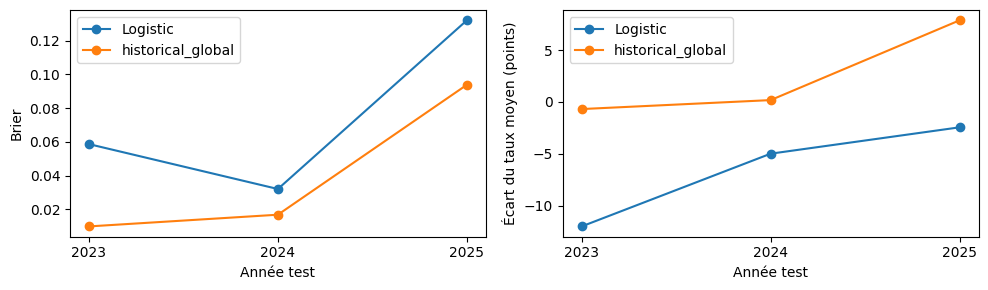

In [3]:
display(results['occurrence'].round(4))
display(results['occurrence_summary'].round(4))
display(results['probabilities'].round(4))
display(results['calibration'].round(4))
fig,axes=plt.subplots(1,2,figsize=(10,3))
for model,g in results['occurrence'].groupby('model'):
    axes[0].plot(g.year,g.brier,marker='o',label=model)
    axes[1].plot(g.year,g.rate_error,marker='o',label=model)
axes[0].set_ylabel('Brier');axes[1].set_ylabel('Écart du taux moyen (points)')
for ax in axes:ax.set_xticks([2023,2024,2025]);ax.set_xlabel('Année test');ax.legend()
plt.tight_layout();plt.show()


## A5–A6 — Baselines, Ridge, ElasticNet et HGB

Baselines limitées à trois : moyenne historique conditionnelle (référence P1, approximation de E[G|transition]), médiane historique globale et médiane de l'année précédente parmi les observations qualifiées. Les médianes sont des comparateurs robustes, pas des espérances conditionnelles.

Évaluation individuelle uniquement sur les 401 / 634 / 773 candidates avec transition observée. Une unité avec plusieurs transitions conserve la moyenne des croissances fondation. Les métriques et médianes sont en points/pourcentage. Les statistiques d'extrêmes utilisent un seuil Q1−3IQR / Q3+3IQR fixé sur train ; aucun extrême retiré.

,year,model,n_train,n_test,mae_pp,rmse_pp,bias_pp,median_absolute_error_pp,median_prediction,median_realized
0,2023,historical_mean,882,401,3.8388,4.9268,0.6691,3.0545,2.8917,2.0854
1,2023,historical_median,882,401,3.8451,4.9306,0.6963,3.0273,2.9189,2.0854
2,2023,previous_year_median,882,401,3.8578,5.0018,-1.0921,2.8197,1.1304,2.0854
3,2023,Ridge,882,401,4.6833,5.6773,2.8580,3.8662,5.1227,2.0854
4,2023,ElasticNet,882,401,4.6776,5.6743,2.8533,3.8336,5.1249,2.0854
5,2023,HGB,882,401,4.1556,5.2330,1.4039,3.4101,3.5189,2.0854
6,2024,historical_mean,1227,634,4.7263,5.9133,1.5015,3.8737,3.4228,1.6996
7,2024,historical_median,1227,634,4.6902,5.8880,1.3986,3.8056,3.3198,1.6996
8,2024,previous_year_median,1227,634,4.6006,5.9440,-1.6184,3.6261,0.3029,1.6996
9,2024,Ridge,1227,634,6.3614,7.4149,4.6758,5.7155,6.5366,1.6996


,model,folds,mean_mae_pp,mean_rmse_pp,mean_abs_bias_pp,worst_year_mae_pp,stability_mae_std_pp
0,historical_mean,3,4.2743,5.6404,0.9726,4.7263,0.3625
1,historical_median,3,4.2718,5.6400,0.9979,4.6902,0.3451
2,previous_year_median,3,4.4995,5.8852,1.8811,5.0401,0.4879
3,Ridge,3,5.0906,6.3720,2.5787,6.3614,0.9178
4,ElasticNet,3,5.0428,6.3270,2.4754,6.2346,0.8635
5,HGB,3,4.6128,5.9384,1.7916,5.2300,0.4530


,year,model,support,mae_pp
0,2023,historical_mean,0,NaN
1,2023,historical_median,0,NaN
2,2023,previous_year_median,0,NaN
3,2023,Ridge,0,NaN
4,2023,ElasticNet,0,NaN
5,2023,HGB,0,NaN
6,2024,historical_mean,1,NaN
7,2024,historical_median,1,NaN
8,2024,previous_year_median,1,NaN
9,2024,Ridge,1,NaN


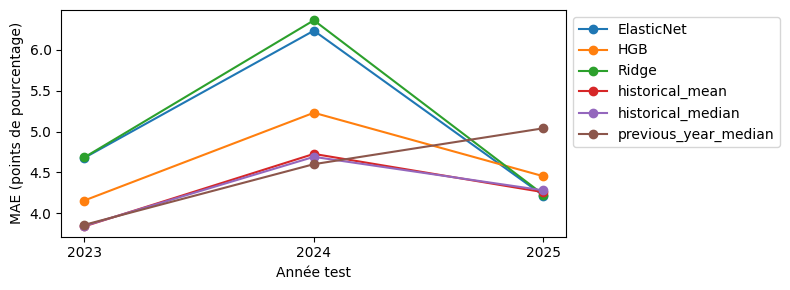

In [4]:
display(results['growth'].round(4))
display(results['growth_summary'].round(4))
display(results['extremes'].round(4))
fig,ax=plt.subplots(figsize=(8,3))
for model,g in results['growth'].groupby('model'):
    ax.plot(g.year,g.mae_pp,marker='o',label=model)
ax.set_xticks([2023,2024,2025]);ax.set_xlabel('Année test');ax.set_ylabel('MAE (points de pourcentage)')
ax.legend(bbox_to_anchor=(1,1));plt.tight_layout();plt.show()


## Interprétation des modèles

Coefficients numériques par écart-type train et catégoriels one-hot par rapport à l'interception. Les codages property_code/building/province sont partiellement redondants : ne pas isoler leur coefficient comme effet autonome. L'année extrapole au-delà des années train ; sa stabilité doit être surveillée. Les signes sont affichés pour chaque origine, sans interprétation causale.

Pour Logistic : un coefficient positif est **associé à une probabilité plus élevée dans le modèle**, négatif à une probabilité plus faible. Pour Ridge/ElasticNet, il est associé à une croissance prédite plus élevée/faible.

HGB : permutation uniquement sur les transitions du fold test, trois répétitions fixes, augmentation du MAE en points. Une importance négative indique qu'une permutation améliore le score observé ; aucune conclusion causale ou sélection de features n'en découle.

In [5]:
coefficients=results['coefficients'].copy()
coefficients['amplitude']=coefficients.coefficient.abs()
top=coefficients.sort_values('amplitude',ascending=False).groupby(['year','model'],sort=False).head(8)
display(top.drop(columns='amplitude').sort_values(['model','year']).round(5))
stable=coefficients.loc[coefficients.feature.isin(['forecast_year','expiry_month','months_since_known_start','prior_contractual_rent'])]
display(stable.pivot(index=['model','feature'],columns='year',values='coefficient').round(5))
display(results['importance'].sort_values(['year','increase_mae_pp'],ascending=[True,False]).groupby('year',sort=False).head(6).round(4))


,year,model,feature,coefficient
45,2023,ElasticNet,forecast_year,0.00671
46,2023,ElasticNet,months_since_known_start,-0.00284
43,2023,ElasticNet,prior_contractual_rent,0.00210
39,2023,ElasticNet,bedrooms,-0.00186
44,2023,ElasticNet,prior_term_months,-0.00125
...,...,...,...,...
163,2025,Ridge,unit_subtype_Studio,-0.00580
149,2025,Ridge,forecast_year,0.00378
148,2025,Ridge,prior_term_months,-0.00323
145,2025,Ridge,sqft,0.00266


year                                    2023     2024     2025
model      feature                                            
ElasticNet forecast_year             0.00671  0.00968  0.00343
           months_since_known_start -0.00284 -0.00125 -0.00005
           prior_contractual_rent    0.00210  0.00196  0.00000
Logistic   expiry_month             -1.99603 -2.30910 -2.24519
           forecast_year            -1.28133 -0.70374 -0.85442
           months_since_known_start  1.30711  1.59418  1.64230
           prior_contractual_rent    0.09170 -0.28491 -0.47044
Ridge      forecast_year             0.00652  0.00954  0.00378
           months_since_known_start -0.00283 -0.00127 -0.00015
           prior_contractual_rent    0.00319  0.00361 -0.00128

,year,feature,increase_mae_pp,std_pp
4,2023,bathrooms,0.0037,0.0011
6,2023,floor,0.0032,0.0109
0,2023,property_code,0.0012,0.0046
1,2023,building,0.0000,0.0000
2,2023,province,0.0000,0.0000
3,2023,bedrooms,0.0000,0.0000
23,2024,months_since_known_start,0.0238,0.0187
21,2024,prior_term_months,0.0078,0.0061
18,2024,floor,0.0036,0.0041
13,2024,building,0.0021,0.0004


## Diagnostic P1 — toutes les combinaisons admissibles

P1 prévu = 100 × médiane(p_hat × g_hat) sur **toute** la cohorte. P1 réalisé = 100 × médiane(O × G), contribution événementielle nulle sans transition. Ce zéro n'affirme aucune stagnation économique du loyer. Les valeurs réalisées doivent reproduire 2,03610 / 1,60785 / 3,30088 %.

Toutes les combinaisons calculables sont affichées, y compris ElasticNet et les comparateurs médians. Le baseline global + moyenne historique doit reproduire les prédictions antérieures. Le comparateur année précédente diffère de l'ancien baseline conditionnel : sa population train est désormais celle des unités/années candidates qualifiées, plutôt que toutes les transitions antérieures. Aucune reproduction artificielle.

In [6]:
display(results['p1'].round(4))
reference=results['p1'].loc[(results['p1'].occurrence_model=='historical_global') & (results['p1'].growth_model=='historical_mean')]
np.testing.assert_allclose(reference.realized_P1_pct,[2.036102349,1.607852406,3.300878457],atol=1e-8)
old=pd.concat([run_portfolio_baselines(leases,y).loc[lambda t:t.baseline.eq('historical_global')] for y in [2023,2024,2025]])
np.testing.assert_allclose(reference.predicted_P1_pct,old.predicted_P1_pct,atol=1e-10)
print('P1 historique reproduit ; aucun champion final sélectionné.')


,year,occurrence_model,growth_model,predicted_P1_pct,realized_P1_pct,error_pp
0,2023,historical_global,historical_mean,2.8434,2.0361,0.8073
1,2023,historical_global,historical_median,2.8701,2.0361,0.8340
2,2023,historical_global,previous_year_median,1.1115,2.0361,-0.9246
3,2023,historical_global,Ridge,5.0426,2.0361,3.0065
4,2023,historical_global,ElasticNet,5.0508,2.0361,3.0147
5,2023,historical_global,HGB,3.4719,2.0361,1.4358
6,2023,Logistic,historical_mean,2.8448,2.0361,0.8087
7,2023,Logistic,historical_median,2.8715,2.0361,0.8354
8,2023,Logistic,previous_year_median,1.1121,2.0361,-0.9240
9,2023,Logistic,Ridge,4.7354,2.0361,2.6993


P1 historique reproduit ; aucun champion final sélectionné.


## Dérive 2025 et conclusion A3–A6

- Le baseline occurrence conserve un meilleur Brier que Logistic dans les trois folds. Logistic rapproche son taux moyen du réalisé en 2025, mais ses probabilités individuelles restent moins bonnes.
- À Saint-Elzear en 2025, Logistic prévoit environ 92,35 % de transitions contre 69,91 % observées : il n'anticipe pas la concentration des absences. Ailleurs, il sous-estime plusieurs taux proches de 98 %.
- Les baselines historiques de croissance ont un MAE moyen voisin de 4,27 points. Le faible avantage MAE de la médiane sur la moyenne ne suffit pas à choisir un champion ; la moyenne reste cohérente avec E[G|transition] et la référence P1.
- Ridge/ElasticNet s'améliorent en 2025 mais surestiment fortement 2023–2024. HGB ne gagne pas sa place face aux références simples.
- Les métriques sont des comparaisons rétrospectives, avec poids égal des années ; elles ne déclenchent aucun tuning ni sélection de features sur le test.
- Pour A7–A9 : occurrence historical_global et croissance historical_mean comme références principales ; conserver historical_median, Ridge/ElasticNet et Logistic comme challengers limités. HGB n'est pas prioritaire. Aucun champion P1 final.
- **GO pour A7–A9 dans le périmètre CORE**, sous les réserves fondation de fidélité CRM, maturité/censure et stabilité interannuelle. Aucun entraînement final ni forecast 2026.

In [7]:
assert all(hashlib.sha256(p.read_bytes()).hexdigest()==v for p,v in hashes.items())
assert not subprocess.run(['git','diff','--cached','--name-only'],cwd=ROOT,capture_output=True,check=True).stdout
print('Intégrité vérifiée : fondation, données brutes/externes et travaux antérieurs inchangés. Rien de staged ; aucun export CRM.')


Intégrité vérifiée : fondation, données brutes/externes et travaux antérieurs inchangés. Rien de staged ; aucun export CRM.
